In [4]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
encoder = LabelEncoder()

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
heart = pd.read_csv("/content/drive/MyDrive/Project Data Analysis/Bangkit Capstone Project/Dataset/Heart Disease.csv")

In [7]:
heart.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [8]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [9]:
heart.duplicated().sum()

0

In [10]:
df = heart.copy()

total_cases = len(df)
positive_cases = df[df['class'] == 'positive'].shape[0]
negative_cases = df[df['class'] == 'negative'].shape[0]

positive_percentage = (positive_cases / total_cases) * 100
negative_percentage = (negative_cases / total_cases) * 100

print("Number of True cases:  {0} ({1:2.2f}%)".format(positive_cases, positive_percentage))
print("Number of False cases: {0} ({1:2.2f}%)".format(negative_cases, negative_percentage))


Number of True cases:  810 (61.41%)
Number of False cases: 509 (38.59%)


In [11]:
categorical_columns = heart[["gender", "class"]]

In [12]:
# Check number of categories in each column
for column in categorical_columns.columns:
    print(f"Column: {column}")
    print(categorical_columns[column].value_counts())
    print()

Column: gender
gender
1    870
0    449
Name: count, dtype: int64

Column: class
class
positive    810
negative    509
Name: count, dtype: int64



In [13]:
df = heart.copy()
le_model = LabelEncoder()

df['class'] = le_model.fit_transform(df['class'])

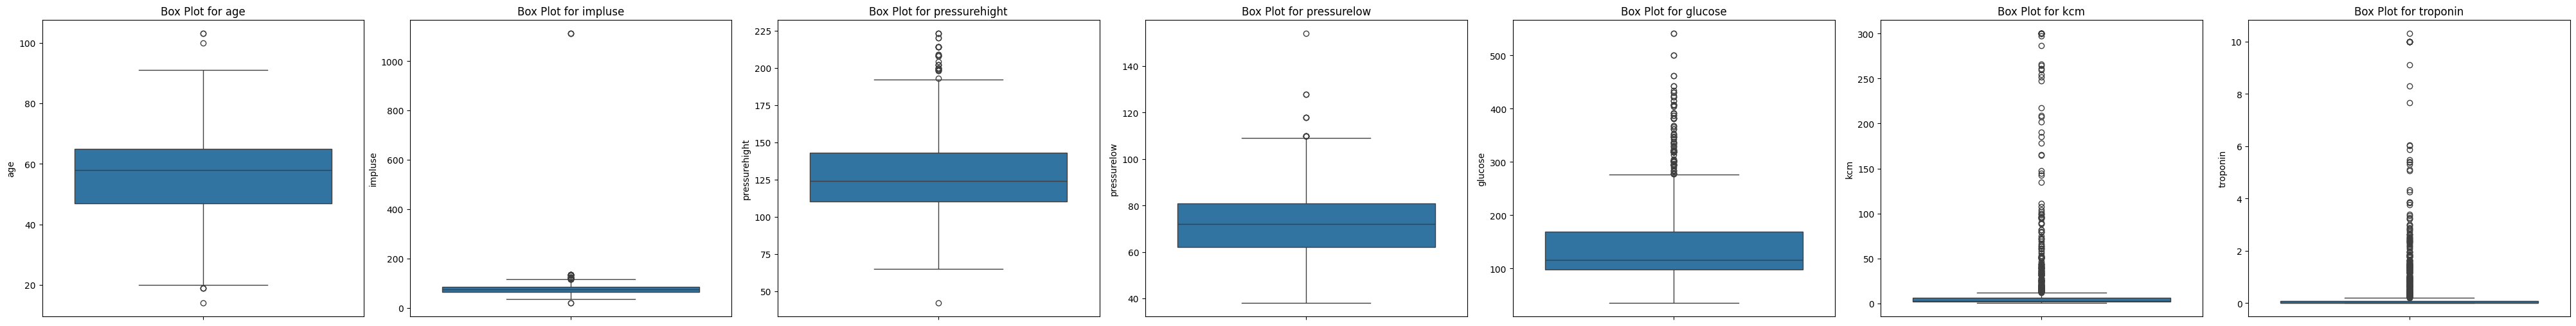

In [14]:
#Identifikasi outlier
numeric_columns = df.columns.drop(['class', 'gender'])
fig, axs = plt.subplots(ncols=len(numeric_columns), figsize=(40, 5))

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=column, data=df, ax=axs[i], whis=1.5)
    axs[i].set_title(f'Box Plot for {column}')
    axs[i].set_xlabel('')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [15]:
from scipy.stats.mstats import winsorize

# Winsorize setiap kolom
for column in numeric_columns:
    df[column] = winsorize(df[column], limits=[0.2, 0.2])

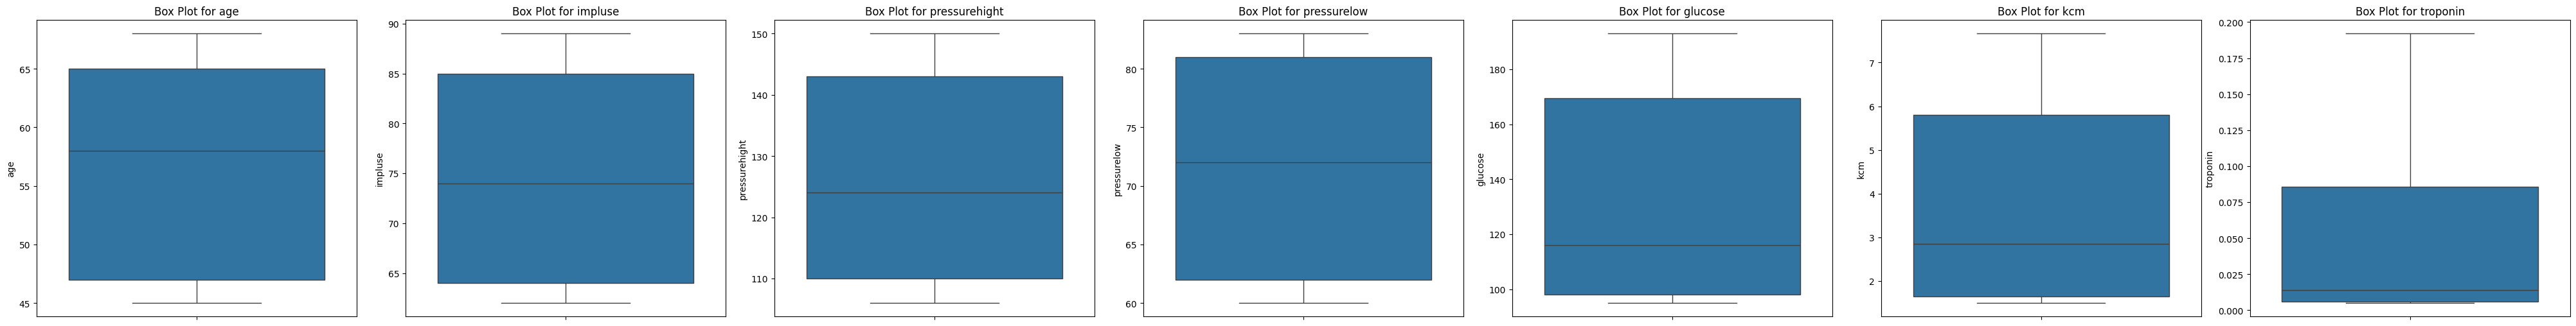

In [16]:
#Identifikasi outlier
numeric_columns = df.columns.drop(['class', 'gender'])
fig, axs = plt.subplots(ncols=len(numeric_columns), figsize=(40, 5))

for i, column in enumerate(numeric_columns):
    sns.boxplot(y=column, data=df, ax=axs[i], whis=1.5)
    axs[i].set_title(f'Box Plot for {column}')
    axs[i].set_xlabel('')

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [17]:
# Separate df_onehot to be X and y
X = df.drop(columns=['class'])  # Features
y = df['class']  # Target variable

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)
importances = model.feature_importances_

# Mengurutkan fitur berdasarkan pentingnya
indices = np.argsort(importances)[::-1]
for f in range(X.shape[1]):
    print(f"{X.columns[indices[f]]}: {importances[indices[f]]}")



troponin: 0.5878305813127712
kcm: 0.280414126263056
age: 0.04297918481868552
pressurehight: 0.021752385392840246
glucose: 0.021494411891236125
impluse: 0.01905092700762316
pressurelow: 0.018508072324654266
gender: 0.007970310989133592


In [19]:
# Mendapatkan pentingnya fitur
importances = model.feature_importances_

# Mengurutkan fitur berdasarkan pentingnya
indices = np.argsort(importances)[::-1]

# Mendapatkan nama kolom dari 5 fitur teratas
top_features = [X.columns[indices[f]] for f in range(6)]
top_features

['troponin', 'kcm', 'age', 'pressurehight', 'glucose', 'impluse']

In [20]:
selected_features = df[['age','troponin', 'kcm', 'glucose', 'pressurehight', 'pressurelow', 'class']]

In [21]:
selected_features

,age,troponin,kcm,glucose,pressurehight,pressurelow,class
0,64,0.012,1.80,160.0,150,83,0
1,45,0.192,6.75,193.0,106,60,1
2,55,0.005,1.99,193.0,150,77,0
3,64,0.122,7.66,193.0,120,60,1
4,55,0.005,1.50,193.0,112,65,0
...,...,...,...,...,...,...,...
1314,45,0.006,1.63,193.0,122,67,0
1315,66,0.172,1.50,149.0,125,60,1
1316,45,0.192,1.50,96.0,150,83,1
1317,54,0.192,5.80,193.0,117,68,1


In [22]:
selected_features.duplicated().sum()

2

In [23]:
df_new = selected_features.drop_duplicates()

In [24]:
X = df_new.drop(columns = 'class', axis = 1)
y = df_new['class']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14045, stratify=y)

In [40]:
# Standardization variable

from sklearn.preprocessing import Normalizer

scaler = Normalizer()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)


Epoch 1/500
27/27 [==============================] - 3s 21ms/step - loss: 0.6726 - accuracy: 0.6223 - val_loss: 0.6817 - val_accuracy: 0.5782
Epoch 2/500
27/27 [==============================] - 0s 6ms/step - loss: 0.6682 - accuracy: 0.6223 - val_loss: 0.6769 - val_accuracy: 0.5782
Epoch 3/500
27/27 [==============================] - 0s 7ms/step - loss: 0.6639 - accuracy: 0.6223 - val_loss: 0.6728 - val_accuracy: 0.5782
Epoch 4/500
27/27 [==============================] - 0s 7ms/step - loss: 0.6596 - accuracy: 0.6223 - val_loss: 0.6687 - val_accuracy: 0.5782
Epoch 5/500
27/27 [==============================] - 0s 8ms/step - loss: 0.6553 - accuracy: 0.6223 - val_loss: 0.6647 - val_accuracy: 0.5782
Epoch 6/500
27/27 [==============================] - 0s 9ms/step - loss: 0.6510 - accuracy: 0.6223 - val_loss: 0.6604 - val_accuracy: 0.5782
Epoch 7/500
27/27 [==============================] - 0s 8ms/step - loss: 0.6466 - accuracy: 0.6223 - val_loss: 0.6569 - val_accuracy: 0.5782
Epoch 8/500


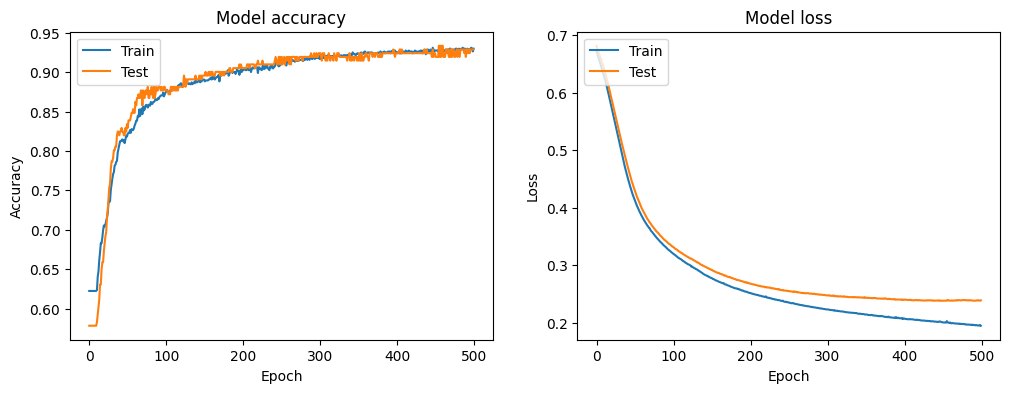

9/9 [==============================] - 0s 3ms/step


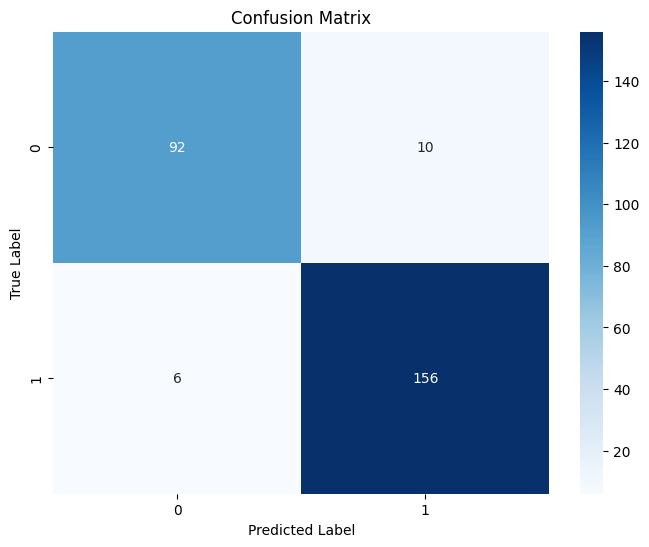

In [44]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from keras.optimizers import SGD, Adam, RMSprop, Nadam
# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32,input_dim = X_train.shape[1], activation = "relu"),
    tf.keras.layers.Dense(16,activation = "relu"),
    tf.keras.layers.Dense(8,activation = "relu"),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train model and store the history
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split = 0.2)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, Accuracy: {accuracy}')

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

# Predict the values from the test dataset
y_pred = model.predict(X_test)
y_pred_classes = np.round(y_pred).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [29]:
y_test.value_counts()

class
1    162
0    102
Name: count, dtype: int64

In [47]:
model.save("/content/Heart.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [48]:
from tensorflow.keras.models import load_model
model = tf.keras.models.load_model("/content/Heart.h5")

In [53]:
# Data dummy
data_dummy = pd.DataFrame({
    'age': [80],
    'troponin': [0.089],
    'kcm': [4],
    'glucose' : [180],
    'pressureheight': [138],
    'presurelow': [68]
})

new_df = scaler.transform(data_dummy)


# Prediksi dengan model
predictions = model.predict(new_df)

# Output hasil prediksi
print("Prediksi probabilitas Heart Disease:", predictions)

# Konversi probabilitas menjadi kelas biner
predicted_classes = (predictions > 0.5).astype("int32")
print("Prediksi kelas Heart Disease (1: Ya, 0: Tidak):", predicted_classes)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but Normalizer was fitted without feature names
  warnings.warn(


1/1 [==============================] - 0s 79ms/step
Prediksi probabilitas Heart Disease: [[0.01210784]]
Prediksi kelas Heart Disease (1: Ya, 0: Tidak): [[0]]
